# Proyecto Integrador - Equipo 16
## Avance 5: Optimización de Prophet para Predicción de Sarampión en México

**Integrantes:**
- Luis Mauricio Castro Gutiérrez - A01795088
- Gerardo Miguel Pérez Solis - A01795599
- Amiel Joel Rosete Islas - A01748598

---

### Objetivos del Avance 5

Basándose en los resultados del Avance 4, donde **SARIMAX demostró ser el modelo con mejor desempeño** (RMSE=10.78), este notebook se enfoca en:

1. **Explorar la estructura de datos**: Mostrar las 30 variables generadas por la ingeniería de características que componen `df_model`.

2. **Optimizar Prophet exhaustivamente** con:
   - **Variable exógena única**: Dosis de vacunación desplazadas temporalmente
   - **Exploración de desfases**: Comparar el efecto de 0, 1, 2 y 3 meses de desplazamiento
   - **Búsqueda exhaustiva de hiperparámetros**: ~100-150 combinaciones
   - **Validación temporal rigurosa**: TimeSeriesSplit con 4 splits

3. **Evaluación integral** usando las métricas del Avance 4:
   - **RMSE** (Root Mean Squared Error)
   - **MAE** (Mean Absolute Error)
   - **SMAPE** (Symmetric Mean Absolute Percentage Error)

4. **Visualización completa**:
   - Serie temporal completa con predicciones
   - Zoom al período de prueba
   - Análisis de residuos
   - Componentes del modelo (tendencia, estacionalidad)

---

### Contexto del Problema

El sarampión es una enfermedad prevenible por vacunación. Este modelo busca predecir casos futuros considerando:
- **Estacionalidad inherente** en la transmisión de enfermedades respiratorias
- **Efecto retardado de la vacunación** sobre la incidencia
- **Períodos inflados por ceros** (meses sin casos registrados)

La separación temporal estricta (**Train ≤ 2018 | Test ≥ 2019**) evita *data leakage* y refleja un escenario realista de pronóstico.

## 1. Configuración del Ambiente y Librerías

In [54]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from copy import deepcopy
from itertools import product

from scipy.stats import nbinom as nbinom_dist
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

from prophet import Prophet

# Configuración global
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
np.seterr(divide="ignore", invalid="ignore")
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

# Constantes
SPLIT_YEAR = 2019
TRAIN_START_YEAR = 2010
TRAIN_END_YEAR = 2018
TEST_START_YEAR = 2019
TEST_END_YEAR = 2023

# Función de métrica SMAPE
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error (0-100%)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1.0, denom)
    return float(100.0 * np.mean(np.abs(y_true - y_pred) / denom))

print("✓ Librerías cargadas correctamente")
print(f"✓ Período de entrenamiento: {TRAIN_START_YEAR}-{TRAIN_END_YEAR}")
print(f"✓ Período de prueba: {TEST_START_YEAR}-{TEST_END_YEAR}")

✓ Librerías cargadas correctamente
✓ Período de entrenamiento: 2010-2018
✓ Período de prueba: 2019-2023


## 2. Carga de Datos y Construcción del Dataset Base

Replicamos el pipeline del Avance 4 para construir `df_model`:
1. Cargar dataset con ingeniería de características (`df_fe`)
2. Cargar dataset de vacunación (`df_vacunas`)
3. Calcular scores de anomalía (Isolation Forest y Bayesian)
4. Integrar vacunas con desplazamiento temporal

In [23]:
base_path = Path("../../..") / "data" / "processed"

# ── 2.1 Dataset de Features Engineered ──
df_fe = pd.read_csv(base_path / "dataset_sarampion_features_engineered.csv")
df_fe["fecha"] = pd.to_datetime(df_fe["fecha"])
df_fe = df_fe.sort_values("fecha").reset_index(drop=True)

# ── 2.2 Dataset de Vacunación ──
df_vacunas = pd.read_csv(base_path / "dataset_sarampion_vacunas_2010-2023.csv")
df_vacunas["fecha"] = pd.to_datetime(
    df_vacunas["anio"].astype(str) + "-" + df_vacunas["mes"].astype(str) + "-01"
)
df_vacunas = df_vacunas.sort_values("fecha").reset_index(drop=True)

# Variable binaria de brote
df_fe["brote"] = (df_fe["casos_sarampion"] > 0).astype(int)
df_vacunas["brote"] = (df_vacunas["casos_sarampion"] > 0).astype(int)

print(f"✓ df_fe cargado: {df_fe.shape}")
print(f"✓ df_vacunas cargado: {df_vacunas.shape}")
print(f"  Período df_fe: {df_fe['fecha'].min().date()} → {df_fe['fecha'].max().date()}")
print(f"  Período vacunas: {df_vacunas['fecha'].min().date()} → {df_vacunas['fecha'].max().date()}")

✓ df_fe cargado: (168, 27)
✓ df_vacunas cargado: (168, 6)
  Período df_fe: 2010-01-01 → 2023-12-01
  Período vacunas: 2010-01-01 → 2023-12-01


### 2.3 Cálculo de Scores de Anomalía (Isolation Forest y Bayesian Hierarchical)

Aunque Prophet solo usará vacunas como regresora, mantenemos estas features en `df_model` para análisis exploratorio.

In [24]:
# ── Isolation Forest Score ──
exclude_cols = {"fecha", "anio", "mes", "casos_sarampion", "brote"} | {
    c for c in df_fe.columns if "pca" in c.lower() or "factor" in c.lower()
}
feature_cols = [c for c in df_fe.columns if c not in exclude_cols]

train_mask = df_fe["anio"] < SPLIT_YEAR
X_train_if = df_fe.loc[train_mask, feature_cols].values
cont_rate = max(df_fe.loc[train_mask, "brote"].mean(), 0.01)

iso_forest = IsolationForest(
    n_estimators=200, contamination=cont_rate, random_state=42, n_jobs=-1
)
iso_forest.fit(X_train_if)
df_fe["isolation_forest_score"] = -iso_forest.decision_function(
    df_fe[feature_cols].values
)

# ── Bayesian Hierarchical Score (Poisson-Gamma) ──
def calcular_bayesian_score(df, split_year=SPLIT_YEAR):
    train_mask = df["anio"] < split_year
    train_raw = df[train_mask]

    global_mean = train_raw["casos_sarampion"].mean()
    global_var = train_raw["casos_sarampion"].var()

    if global_var > global_mean and global_mean > 0:
        beta_0 = global_mean / max(global_var, 1e-6)
        alpha_0 = global_mean * beta_0
    else:
        alpha_0, beta_0 = 0.5, 0.5

    posteriors = {}
    for mes in range(1, 13):
        month_data = train_raw[train_raw["mes"] == mes]["casos_sarampion"]
        posteriors[mes] = (alpha_0 + int(month_data.sum()), beta_0 + len(month_data))

    pvalues = np.zeros(len(df))
    for idx in range(len(df)):
        mes = int(df.iloc[idx]["mes"])
        y_obs = int(df.iloc[idx]["casos_sarampion"])
        alpha_post, beta_post = posteriors[mes]
        r, p = alpha_post, beta_post / (1.0 + beta_post)
        pvalues[idx] = (
            1.0 - nbinom_dist.cdf(y_obs - 1, r, p) if y_obs > 0 else 1.0
        )
    return 1.0 - pvalues

bayesian_scores = calcular_bayesian_score(df_vacunas)
df_bayes = pd.DataFrame({
    "fecha": df_vacunas["fecha"],
    "bayesian_score": bayesian_scores,
})
df_fe = df_fe.merge(df_bayes, on="fecha", how="left")

print(f"\n✓ Isolation Forest Score range: [{df_fe['isolation_forest_score'].min():.4f}, {df_fe['isolation_forest_score'].max():.4f}]")
print(f"✓ Bayesian Score range: [{df_fe['bayesian_score'].min():.4f}, {df_fe['bayesian_score'].max():.4f}]")


✓ Isolation Forest Score range: [-0.2365, 0.1137]
✓ Bayesian Score range: [0.0000, 1.0000]


### 2.4 Función de Integración de Vacunas con Desplazamiento Temporal

In [25]:
def integrar_vacunas_con_desfase(df_principal, df_vac, desfase_meses=0):
    """
    Integra las dosis de vacunación con desplazamiento temporal.
    
    Parámetros:
    -----------
    df_principal : DataFrame
        Dataset principal con features
    df_vac : DataFrame
        Dataset de vacunación con columna 'total_dosis'
    desfase_meses : int
        Número de meses de desplazamiento (efecto retardado de vacunación)
    
    Retorna:
    --------
    DataFrame con columna 'total_dosis_lag_{desfase_meses}m' agregada
    """
    df_vac_lag = df_vac.copy()
    df_vac_lag["fecha_join"] = df_vac_lag["fecha"] + pd.DateOffset(months=desfase_meses)
    col_name = f"total_dosis_lag_{desfase_meses}m"
    df_vac_lag = df_vac_lag[["fecha_join", "total_dosis"]].rename(
        columns={"total_dosis": col_name}
    )
    df_res = pd.merge(
        df_principal, df_vac_lag, left_on="fecha", right_on="fecha_join", how="left"
    )
    df_res.drop(columns=["fecha_join"], inplace=True)
    df_res.dropna(subset=[col_name], inplace=True)
    return df_res.reset_index(drop=True)

print("✓ Función de integración de vacunas definida")

✓ Función de integración de vacunas definida


---
## 3. Exploración de la Estructura de `df_model`

**Pregunta clave del Avance 5**: ¿Cuáles son las 30 variables que componen `df_model`?

Construimos `df_model` con desfase de 2 meses (valor usado en Avance 4) y exploramos su estructura.

In [26]:
# Construir df_model con desfase de 2 meses (referencia del Avance 4)
DESFASE_REFERENCIA = 2
df_model = integrar_vacunas_con_desfase(df_fe, df_vacunas, desfase_meses=DESFASE_REFERENCIA)

# Filtrar período de análisis
df_model = df_model[
    (df_model["anio"] >= TRAIN_START_YEAR) & (df_model["anio"] <= TEST_END_YEAR)
].copy()

print(f"{'='*80}")
print(f"  ESTRUCTURA DE df_model")
print(f"{'='*80}")
print(f"\n✓ Dimensiones: {df_model.shape}")
print(f"✓ Período: {df_model['fecha'].min().date()} → {df_model['fecha'].max().date()}")
print(f"✓ Total de registros: {len(df_model)}")
print(f"\n{'─'*80}")
print(f"  LISTADO COMPLETO DE VARIABLES (Total: {len(df_model.columns)})")
print(f"{'─'*80}\n")

# Categorizar variables por tipo
variables_meta = ["fecha", "anio", "mes"]
variables_target = ["casos_sarampion", "brote"]
variables_lags = [c for c in df_model.columns if "lag" in c.lower()]
variables_rolling = [c for c in df_model.columns if "rolling" in c.lower() or "ma" in c.lower()]
variables_estacionales = [c for c in df_model.columns if any(x in c.lower() for x in ["sin", "cos", "estacion"])]
variables_anomalia = ["isolation_forest_score", "bayesian_score"]
variables_vacunas = [c for c in df_model.columns if "dosis" in c.lower() and "lag" in c.lower()]
variables_otras = [c for c in df_model.columns if c not in 
                   variables_meta + variables_target + variables_lags + 
                   variables_rolling + variables_estacionales + variables_anomalia + 
                   variables_vacunas and "pca" not in c.lower() and "factor" not in c.lower()]

# Mostrar por categorías
categorias = [
    ("Metadatos", variables_meta),
    ("Variable Objetivo", variables_target),
    ("Lags del Target", variables_lags),
    ("Medias Móviles y Rolling", variables_rolling),
    ("Features Estacionales", variables_estacionales),
    ("Scores de Anomalía", variables_anomalia),
    ("Vacunación con Desfase", variables_vacunas),
    ("Otras Features", variables_otras),
]

for idx, (categoria, cols) in enumerate(categorias, 1):
    if cols:
        print(f"{idx}. {categoria} ({len(cols)} variables):")
        for col in cols:
            dtype = df_model[col].dtype
            print(f"   • {col:<40} | dtype: {dtype}")
        print()

# Resumen de las 30+ variables predictoras (excluyendo metadata y target)
cols_excl = {"fecha", "anio", "mes", "casos_sarampion", "brote"} | {
    c for c in df_model.columns if "pca" in c.lower() or "factor" in c.lower()
}
model_features = [c for c in df_model.columns if c not in cols_excl]

print(f"{'─'*80}")
print(f"  RESUMEN: Variables Predictoras para Modelado")
print(f"{'─'*80}")
print(f"Total de features disponibles: {len(model_features)}")
print(f"\nListado:")
for i, feat in enumerate(model_features, 1):
    print(f"{i:2d}. {feat}")

  ESTRUCTURA DE df_model

✓ Dimensiones: (166, 30)
✓ Período: 2010-03-01 → 2023-12-01
✓ Total de registros: 166

────────────────────────────────────────────────────────────────────────────────
  LISTADO COMPLETO DE VARIABLES (Total: 30)
────────────────────────────────────────────────────────────────────────────────

1. Metadatos (3 variables):
   • fecha                                    | dtype: datetime64[ns]
   • anio                                     | dtype: int64
   • mes                                      | dtype: int64

2. Variable Objetivo (2 variables):
   • casos_sarampion                          | dtype: int64
   • brote                                    | dtype: int32

3. Lags del Target (3 variables):
   • dosis_lag_14m_log                        | dtype: float64
   • dosis_lag_13m_log                        | dtype: float64
   • total_dosis_lag_2m                       | dtype: float64

4. Medias Móviles y Rolling (4 variables):
   • casos_rolling_mean_3m_log   

### Estadísticas Descriptivas de Variables Clave


Estadísticas Descriptivas de Variables Clave:


,count,mean,std,min,25%,50%,75%,max
casos_sarampion,166.0,2.289157,11.197435,0.000000,0.0000,0.000000,0.000000,8.100000e+01
total_dosis_lag_2m,166.0,315917.102410,358817.021916,11155.000000,179379.2500,229233.000000,316194.750000,3.130610e+06
isolation_forest_score,166.0,-0.133429,0.097230,-0.236532,-0.2133,-0.172939,-0.076751,1.136626e-01
bayesian_score,166.0,0.091470,0.282889,0.000000,0.0000,0.000000,0.000000,1.000000e+00


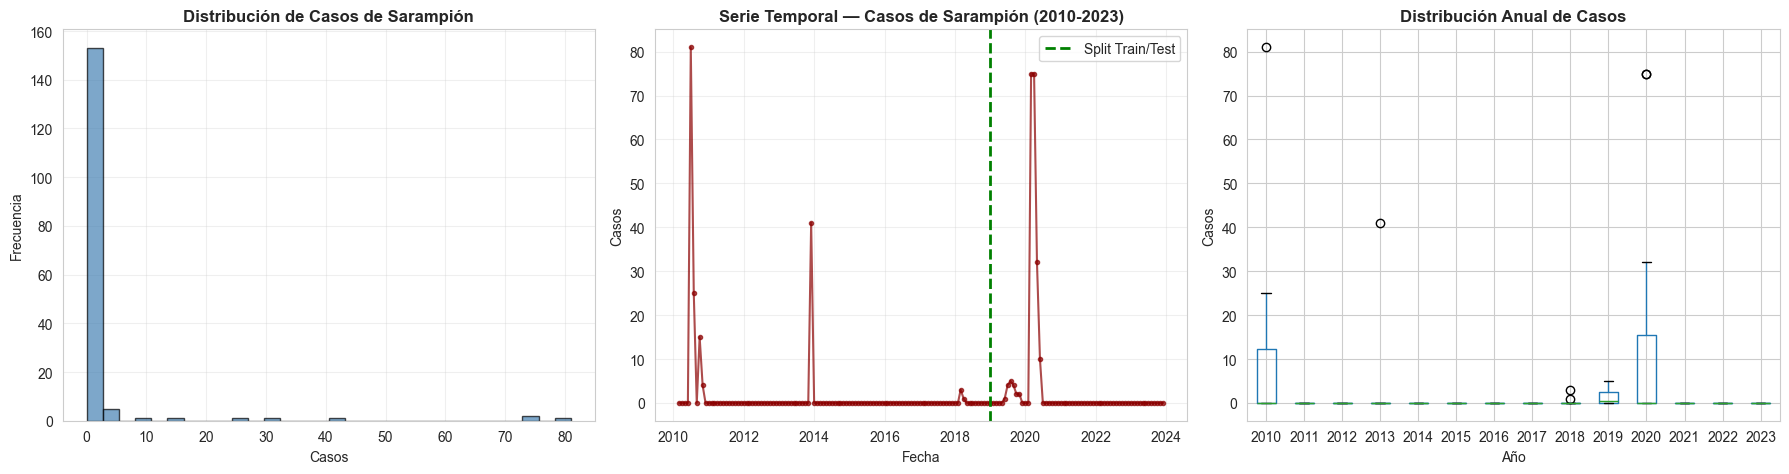


📊 Porcentaje de meses con cero casos: 89.76%
📊 Meses con al menos un caso: 17 / 166


In [27]:
# Estadísticas del target y variable exógena principal
stats_cols = ["casos_sarampion", f"total_dosis_lag_{DESFASE_REFERENCIA}m", 
              "isolation_forest_score", "bayesian_score"]
stats_disponibles = [c for c in stats_cols if c in df_model.columns]

print("\nEstadísticas Descriptivas de Variables Clave:")
print("="*80)
display(df_model[stats_disponibles].describe().T)

# Distribución del target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
axes[0].hist(df_model["casos_sarampion"], bins=30, color="steelblue", alpha=0.7, edgecolor="black")
axes[0].set_title("Distribución de Casos de Sarampión", fontweight="bold")
axes[0].set_xlabel("Casos")
axes[0].set_ylabel("Frecuencia")
axes[0].grid(True, alpha=0.3)

# Serie temporal
axes[1].plot(df_model["fecha"], df_model["casos_sarampion"], "o-", ms=3, alpha=0.7, color="darkred")
axes[1].set_title("Serie Temporal — Casos de Sarampión (2010-2023)", fontweight="bold")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Casos")
axes[1].grid(True, alpha=0.3)
axes[1].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="green", ls="--", lw=2, label="Split Train/Test")
axes[1].legend()

# Boxplot por año
df_model.boxplot(column="casos_sarampion", by="anio", ax=axes[2])
axes[2].set_title("Distribución Anual de Casos", fontweight="bold")
axes[2].set_xlabel("Año")
axes[2].set_ylabel("Casos")
axes[2].get_figure().suptitle("")

plt.tight_layout()
plt.show()

# Meses inflados por ceros
pct_zeros = (df_model["casos_sarampion"] == 0).sum() / len(df_model) * 100
print(f"\n📊 Porcentaje de meses con cero casos: {pct_zeros:.2f}%")
print(f"📊 Meses con al menos un caso: {(df_model['casos_sarampion'] > 0).sum()} / {len(df_model)}")

---
## 4. Preparación de Datasets para Prophet con Diferentes Desfases

Evaluaremos el impacto del desplazamiento temporal de vacunas probando **desfases de 0, 1, 2 y 3 meses**.

**Hipótesis**: Un desfase mayor puede capturar mejor el efecto protector de la vacunación sobre la incidencia de sarampión.

In [28]:
# Desfases a evaluar
DESFASES = [0, 1, 2, 3]

# Diccionario para almacenar datasets
datasets_por_desfase = {}

for desfase in DESFASES:
    # Construir dataset
    df_temp = integrar_vacunas_con_desfase(df_fe, df_vacunas, desfase_meses=desfase)
    df_temp = df_temp[
        (df_temp["anio"] >= TRAIN_START_YEAR) & (df_temp["anio"] <= TEST_END_YEAR)
    ].copy()
    
    # Preparar para Prophet (formato requerido: 'ds' y 'y')
    col_vacuna = f"total_dosis_lag_{desfase}m"
    
    df_prophet = pd.DataFrame({
        "ds": df_temp["fecha"],
        "y": df_temp["casos_sarampion"].astype(float),
        "vacunas": df_temp[col_vacuna].astype(float),
        "anio": df_temp["anio"],
    })
    
    # Particionar train/test
    train_mask = df_prophet["anio"] <= TRAIN_END_YEAR
    test_mask = df_prophet["anio"] >= TEST_START_YEAR
    
    df_train = df_prophet[train_mask].drop(columns=["anio"]).reset_index(drop=True)
    df_test = df_prophet[test_mask].drop(columns=["anio"]).reset_index(drop=True)
    
    datasets_por_desfase[desfase] = {
        "full": df_prophet,
        "train": df_train,
        "test": df_test,
        "col_vacuna": col_vacuna,
    }
    
    print(f"✓ Desfase {desfase}m: Train={len(df_train)}, Test={len(df_test)}, Variable='{col_vacuna}'")

print(f"\n✓ {len(DESFASES)} configuraciones de desfase preparadas")

✓ Desfase 0m: Train=108, Test=60, Variable='total_dosis_lag_0m'
✓ Desfase 1m: Train=107, Test=60, Variable='total_dosis_lag_1m'
✓ Desfase 2m: Train=106, Test=60, Variable='total_dosis_lag_2m'
✓ Desfase 3m: Train=105, Test=60, Variable='total_dosis_lag_3m'

✓ 4 configuraciones de desfase preparadas


---
## 5. Grid Search Exhaustivo de Hiperparámetros con TimeSeriesSplit

Prophet tiene varios hiperparámetros críticos:

| Hiperparámetro | Descripción | Valores a Probar |
|----------------|-------------|------------------|
| `changepoint_prior_scale` | Flexibilidad de la tendencia | [0.001, 0.01, 0.05, 0.1, 0.5, 1.0] |
| `seasonality_prior_scale` | Fuerza de la estacionalidad | [0.1, 1.0, 5.0, 10.0, 20.0] |
| `seasonality_mode` | Tipo de estacionalidad | ['additive', 'multiplicative'] |
| `yearly_seasonality` | Activar estacionalidad anual | [True, False] |

**Estrategia de búsqueda**:
- Combinaciones totales: 6 × 5 × 2 × 2 = **120 configuraciones**
- Validación: **TimeSeriesSplit con 4 splits** sobre el conjunto de entrenamiento
- Métrica de optimización: **RMSE** (consistente con Avance 4)

In [29]:
# Definir grid de hiperparámetros
param_grid_prophet = {
    "changepoint_prior_scale": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    "seasonality_prior_scale": [0.1, 1.0, 5.0, 10.0, 20.0],
    "seasonality_mode": ["additive", "multiplicative"],
    "yearly_seasonality": [True, False],
}

# Generar todas las combinaciones
all_combinations = list(product(
    param_grid_prophet["changepoint_prior_scale"],
    param_grid_prophet["seasonality_prior_scale"],
    param_grid_prophet["seasonality_mode"],
    param_grid_prophet["yearly_seasonality"],
))

print(f"{'='*80}")
print(f"  CONFIGURACIÓN DE GRID SEARCH")
print(f"{'='*80}")
print(f"Total de combinaciones de hiperparámetros: {len(all_combinations)}")
print(f"Desfases de vacunación a evaluar: {DESFASES}")
print(f"Total de experimentos: {len(all_combinations) * len(DESFASES)}")
print(f"Splits de validación temporal: 4")
print(f"\n⏱️  Tiempo estimado: 30-60 minutos (dependiendo del hardware)")
print(f"{'='*80}\n")

  CONFIGURACIÓN DE GRID SEARCH
Total de combinaciones de hiperparámetros: 120
Desfases de vacunación a evaluar: [0, 1, 2, 3]
Total de experimentos: 480
Splits de validación temporal: 4

⏱️  Tiempo estimado: 30-60 minutos (dependiendo del hardware)



In [30]:
# Función para validación cruzada temporal
def cv_prophet_time_series(df_train, params, n_splits=4, verbose=False):
    """
    Validación cruzada temporal para Prophet usando TimeSeriesSplit.
    
    Retorna el RMSE promedio sobre los splits de validación.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rmses = []
    errors = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(df_train)):
        # Particionar fold
        train_fold = df_train.iloc[train_idx].copy()
        val_fold = df_train.iloc[val_idx].copy()
        
        try:
            # Entrenar modelo Prophet
            model = Prophet(
                changepoint_prior_scale=params["changepoint_prior_scale"],
                seasonality_prior_scale=params["seasonality_prior_scale"],
                seasonality_mode=params["seasonality_mode"],
                yearly_seasonality=params["yearly_seasonality"],
                weekly_seasonality=False,
                daily_seasonality=False,
            )
            model.add_regressor("vacunas")
            model.fit(train_fold)
            
            # Predecir en validación
            forecast = model.predict(val_fold[["ds", "vacunas"]])
            y_pred = np.clip(forecast["yhat"].values, 0, None)
            y_true = val_fold["y"].values
            
            # Calcular RMSE
            rmse_fold = np.sqrt(mean_squared_error(y_true, y_pred))
            rmses.append(rmse_fold)
            
        except Exception as e:
            # Guardar error para debugging
            errors.append(str(e))
            if verbose:
                print(f"    Error en fold {fold_idx}: {str(e)[:100]}")
    
    # Si todos los folds fallaron, retornar inf
    if len(rmses) == 0:
        if verbose:
            print(f"    ⚠️ TODOS los folds fallaron. Primer error: {errors[0][:200] if errors else 'N/A'}")
        return np.inf
    
    # Si algunos folds funcionaron, retornar promedio
    return np.mean(rmses)


print("✓ Función de validación cruzada temporal definida")

✓ Función de validación cruzada temporal definida


### Diagnóstico Pre-Grid Search

Antes de ejecutar el grid search, verificamos que los datos estén correctamente formateados para Prophet.

In [31]:
# Verificación de datos antes del grid search
print("="*80)
print("  DIAGNÓSTICO PRE-GRID SEARCH")
print("="*80)

for desfase in DESFASES:
    print(f"\n{'─'*80}")
    print(f"  Desfase: {desfase} meses")
    print(f"{'─'*80}")
    
    df_check = datasets_por_desfase[desfase]["train"]
    
    # Verificar estructura
    print(f"  ✓ Forma del dataset: {df_check.shape}")
    print(f"  ✓ Columnas: {list(df_check.columns)}")
    print(f"  ✓ Tipos de datos:")
    print(f"    • ds: {df_check['ds'].dtype}")
    print(f"    • y: {df_check['y'].dtype}")
    print(f"    • vacunas: {df_check['vacunas'].dtype}")
    
    # Verificar valores nulos
    nulls = df_check.isnull().sum()
    if nulls.sum() > 0:
        print(f"  ⚠️  Valores nulos encontrados:")
        print(nulls[nulls > 0])
    else:
        print(f"  ✓ Sin valores nulos")
    
    # Verificar valores infinitos o negativos
    inf_y = np.isinf(df_check['y']).sum()
    inf_vac = np.isinf(df_check['vacunas']).sum()
    neg_y = (df_check['y'] < 0).sum()
    neg_vac = (df_check['vacunas'] < 0).sum()
    
    if inf_y > 0 or inf_vac > 0 or neg_y > 0 or neg_vac > 0:
        print(f"  ⚠️  Problemas detectados:")
        if inf_y > 0: print(f"    • Infinitos en 'y': {inf_y}")
        if inf_vac > 0: print(f"    • Infinitos en 'vacunas': {inf_vac}")
        if neg_y > 0: print(f"    • Negativos en 'y': {neg_y}")
        if neg_vac > 0: print(f"    • Negativos en 'vacunas': {neg_vac}")
    else:
        print(f"  ✓ Sin infinitos ni negativos")
    
    # Estadísticas básicas
    print(f"  ✓ Estadísticas de 'y': min={df_check['y'].min():.2f}, max={df_check['y'].max():.2f}, mean={df_check['y'].mean():.2f}")
    print(f"  ✓ Estadísticas de 'vacunas': min={df_check['vacunas'].min():.0f}, max={df_check['vacunas'].max():.0f}, mean={df_check['vacunas'].mean():.0f}")
    
    # Verificar TimeSeriesSplit
    tscv_check = TimeSeriesSplit(n_splits=4)
    n_splits_actual = sum(1 for _ in tscv_check.split(df_check))
    print(f"  ✓ TimeSeriesSplit generará {n_splits_actual} splits")
    
    # Tamaño mínimo de cada fold
    min_train_size = min(len(train_idx) for train_idx, _ in tscv_check.split(df_check))
    min_val_size = min(len(val_idx) for _, val_idx in tscv_check.split(df_check))
    print(f"  ✓ Tamaño mínimo - Train: {min_train_size}, Val: {min_val_size}")

print(f"\n{'='*80}")
print("✓ Diagnóstico completado. Si todo está correcto, proceder con el grid search.")
print("="*80)

  DIAGNÓSTICO PRE-GRID SEARCH

────────────────────────────────────────────────────────────────────────────────
  Desfase: 0 meses
────────────────────────────────────────────────────────────────────────────────
  ✓ Forma del dataset: (108, 3)
  ✓ Columnas: ['ds', 'y', 'vacunas']
  ✓ Tipos de datos:
    • ds: datetime64[ns]
    • y: float64
    • vacunas: float64
  ✓ Sin valores nulos
  ✓ Sin infinitos ni negativos
  ✓ Estadísticas de 'y': min=0.00, max=81.00, mean=1.57
  ✓ Estadísticas de 'vacunas': min=38792, max=3130610, mean=317372
  ✓ TimeSeriesSplit generará 4 splits
  ✓ Tamaño mínimo - Train: 24, Val: 21

────────────────────────────────────────────────────────────────────────────────
  Desfase: 1 meses
────────────────────────────────────────────────────────────────────────────────
  ✓ Forma del dataset: (107, 3)
  ✓ Columnas: ['ds', 'y', 'vacunas']
  ✓ Tipos de datos:
    • ds: datetime64[ns]
    • y: float64
    • vacunas: float64
  ✓ Sin valores nulos
  ✓ Sin infinitos ni ne

### Ejecución del Grid Search

**Advertencia**: Este proceso puede tardar entre 30-60 minutos. Se muestra progreso cada 10 combinaciones.

In [32]:
# Almacenar resultados del grid search
resultados_grid = []
best_config_global = {"rmse_cv": np.inf, "desfase": None, "params": None}

print(f"\n{'='*80}")
print(f"  INICIANDO GRID SEARCH EXHAUSTIVO")
print(f"{'='*80}\n")

# Contador de éxitos/fallos
total_exitosos = 0
total_fallidos = 0

for desfase in DESFASES:
    print(f"\n{'─'*80}")
    print(f"  DESFASE: {desfase} MESES")
    print(f"{'─'*80}")
    
    df_train_desfase = datasets_por_desfase[desfase]["train"]
    best_config_desfase = {"rmse_cv": np.inf, "desfase": desfase, "params": None}
    
    for idx, (cps, sps, mode, yearly) in enumerate(all_combinations, 1):
        params = {
            "changepoint_prior_scale": cps,
            "seasonality_prior_scale": sps,
            "seasonality_mode": mode,
            "yearly_seasonality": yearly,
        }
        
        # Validación cruzada (verbose en primera iteración para debugging)
        verbose_debug = (idx == 1 and desfase == DESFASES[0])
        rmse_cv = cv_prophet_time_series(df_train_desfase, params, n_splits=4, verbose=verbose_debug)
        
        # Contar éxitos/fallos
        if rmse_cv == np.inf:
            total_fallidos += 1
        else:
            total_exitosos += 1
        
        # Guardar resultado
        resultados_grid.append({
            "desfase_meses": desfase,
            "changepoint_prior_scale": cps,
            "seasonality_prior_scale": sps,
            "seasonality_mode": mode,
            "yearly_seasonality": yearly,
            "rmse_cv": rmse_cv,
        })
        
        # Actualizar mejor configuración para este desfase
        if rmse_cv < best_config_desfase["rmse_cv"]:
            best_config_desfase = {
                "desfase": desfase,
                "params": params.copy(),
                "rmse_cv": rmse_cv,
            }
        
        # Actualizar mejor configuración global
        if rmse_cv < best_config_global["rmse_cv"]:
            best_config_global = {
                "desfase": desfase,
                "params": params.copy(),
                "rmse_cv": rmse_cv,
            }
        
        # Mostrar progreso cada 10 iteraciones
        if idx % 10 == 0:
            current_best = best_config_desfase['rmse_cv']
            status = f"{current_best:.4f}" if current_best != np.inf else "inf"
            print(f"  Progreso: {idx}/{len(all_combinations)} combinaciones | Mejor RMSE_CV: {status}")
    
    # Resumen del mejor para este desfase
    print(f"\n  ★ Mejor configuración para desfase {desfase}m:")
    if best_config_desfase['params'] is not None:
        print(f"    RMSE_CV: {best_config_desfase['rmse_cv']:.4f}")
        print(f"    Params: {best_config_desfase['params']}")
    else:
        print(f"    ⚠️  TODAS las combinaciones fallaron (RMSE_CV = inf)")
        print(f"    Revisar configuración de datos o parámetros de Prophet")

print(f"\n{'='*80}")
print(f"  GRID SEARCH COMPLETADO")
print(f"{'='*80}")
print(f"\n📊 Resumen de Ejecución:")
print(f"   Total de combinaciones probadas: {len(resultados_grid)}")
print(f"   Exitosas: {total_exitosos}")
print(f"   Fallidas: {total_fallidos}")

if best_config_global['params'] is not None:
    print(f"\n🏆 MEJOR CONFIGURACIÓN GLOBAL:")
    print(f"   Desfase: {best_config_global['desfase']} meses")
    print(f"   RMSE_CV: {best_config_global['rmse_cv']:.4f}")
    print(f"   Hiperparámetros:")
    for k, v in best_config_global['params'].items():
        print(f"     • {k}: {v}")
else:
    print(f"\n❌ ERROR: Todas las configuraciones fallaron.")
    print(f"\n🔍 Diagnóstico sugerido:")
    print(f"   1. Verificar que df_train tenga el formato correcto para Prophet (columnas 'ds', 'y', 'vacunas')")
    print(f"   2. Revisar que no haya valores NaN o infinitos en los datos")
    print(f"   3. Verificar tamaño mínimo de datos para TimeSeriesSplit")
    print(f"\n   Ejecutar esta celda para diagnóstico detallado:")
    print(f"   df_train_sample = datasets_por_desfase[0]['train']")
    print(f"   print(df_train_sample.info())")
    print(f"   print(df_train_sample.describe())")
    print(f"   print(df_train_sample.isnull().sum())")

16:51:30 - cmdstanpy - INFO - Chain [1] start processing



  INICIANDO GRID SEARCH EXHAUSTIVO


────────────────────────────────────────────────────────────────────────────────
  DESFASE: 0 MESES
────────────────────────────────────────────────────────────────────────────────


16:51:31 - cmdstanpy - INFO - Chain [1] done processing
16:51:31 - cmdstanpy - INFO - Chain [1] start processing
16:51:31 - cmdstanpy - INFO - Chain [1] done processing
16:51:31 - cmdstanpy - INFO - Chain [1] start processing
16:51:31 - cmdstanpy - INFO - Chain [1] done processing
16:51:31 - cmdstanpy - INFO - Chain [1] start processing
16:51:31 - cmdstanpy - INFO - Chain [1] done processing
16:51:31 - cmdstanpy - INFO - Chain [1] start processing
16:51:32 - cmdstanpy - INFO - Chain [1] done processing
16:51:32 - cmdstanpy - INFO - Chain [1] start processing
16:51:32 - cmdstanpy - INFO - Chain [1] done processing
16:51:32 - cmdstanpy - INFO - Chain [1] start processing
16:51:32 - cmdstanpy - INFO - Chain [1] done processing
16:51:32 - cmdstanpy - INFO - Chain [1] start processing
16:51:32 - cmdstanpy - INFO - Chain [1] done processing
16:51:32 - cmdstanpy - INFO - Chain [1] start processing
16:51:32 - cmdstanpy - INFO - Chain [1] done processing
16:51:32 - cmdstanpy - INFO - Chain [1] 

  Progreso: 10/120 combinaciones | Mejor RMSE_CV: 2.4092


16:51:40 - cmdstanpy - INFO - Chain [1] start processing
16:51:42 - cmdstanpy - INFO - Chain [1] done processing
16:51:42 - cmdstanpy - INFO - Chain [1] start processing
16:51:43 - cmdstanpy - INFO - Chain [1] done processing
16:51:43 - cmdstanpy - INFO - Chain [1] start processing
16:51:44 - cmdstanpy - INFO - Chain [1] done processing
16:51:44 - cmdstanpy - INFO - Chain [1] start processing
16:51:44 - cmdstanpy - INFO - Chain [1] done processing
16:51:44 - cmdstanpy - INFO - Chain [1] start processing
16:51:44 - cmdstanpy - INFO - Chain [1] done processing
16:51:44 - cmdstanpy - INFO - Chain [1] start processing
16:51:45 - cmdstanpy - INFO - Chain [1] done processing
16:51:45 - cmdstanpy - INFO - Chain [1] start processing
16:51:45 - cmdstanpy - INFO - Chain [1] done processing
16:51:45 - cmdstanpy - INFO - Chain [1] start processing
16:51:45 - cmdstanpy - INFO - Chain [1] done processing
16:51:45 - cmdstanpy - INFO - Chain [1] start processing
16:51:46 - cmdstanpy - INFO - Chain [1]

...

  Progreso: 100/120 combinaciones | Mejor RMSE_CV: 2.4091


17:40:39 - cmdstanpy - INFO - Chain [1] start processing
17:40:39 - cmdstanpy - INFO - Chain [1] done processing
17:40:39 - cmdstanpy - INFO - Chain [1] start processing
17:40:40 - cmdstanpy - INFO - Chain [1] done processing
17:40:40 - cmdstanpy - INFO - Chain [1] start processing
17:40:40 - cmdstanpy - INFO - Chain [1] done processing
17:40:40 - cmdstanpy - INFO - Chain [1] start processing
17:40:40 - cmdstanpy - INFO - Chain [1] done processing
17:40:40 - cmdstanpy - INFO - Chain [1] start processing
17:40:41 - cmdstanpy - INFO - Chain [1] done processing
17:40:41 - cmdstanpy - INFO - Chain [1] start processing
17:40:41 - cmdstanpy - INFO - Chain [1] done processing
17:40:41 - cmdstanpy - INFO - Chain [1] start processing
17:40:41 - cmdstanpy - INFO - Chain [1] done processing
17:40:41 - cmdstanpy - INFO - Chain [1] start processing
17:40:47 - cmdstanpy - INFO - Chain [1] done processing
17:40:47 - cmdstanpy - INFO - Chain [1] start processing
17:40:59 - cmdstanpy - INFO - Chain [1]

  Progreso: 110/120 combinaciones | Mejor RMSE_CV: 2.4091


17:42:28 - cmdstanpy - INFO - Chain [1] done processing
17:42:28 - cmdstanpy - INFO - Chain [1] start processing
17:42:40 - cmdstanpy - INFO - Chain [1] done processing
17:42:40 - cmdstanpy - INFO - Chain [1] start processing
17:42:55 - cmdstanpy - INFO - Chain [1] done processing
17:42:55 - cmdstanpy - INFO - Chain [1] start processing
17:43:12 - cmdstanpy - INFO - Chain [1] done processing
17:43:12 - cmdstanpy - INFO - Chain [1] start processing
17:43:12 - cmdstanpy - INFO - Chain [1] done processing
17:43:12 - cmdstanpy - INFO - Chain [1] start processing
17:43:12 - cmdstanpy - INFO - Chain [1] done processing
17:43:13 - cmdstanpy - INFO - Chain [1] start processing
17:43:13 - cmdstanpy - INFO - Chain [1] done processing
17:43:13 - cmdstanpy - INFO - Chain [1] start processing
17:43:13 - cmdstanpy - INFO - Chain [1] done processing
17:43:13 - cmdstanpy - INFO - Chain [1] start processing
17:43:19 - cmdstanpy - INFO - Chain [1] done processing
17:43:19 - cmdstanpy - INFO - Chain [1] 

  Progreso: 120/120 combinaciones | Mejor RMSE_CV: 2.4091

  ★ Mejor configuración para desfase 3m:
    RMSE_CV: 2.4091
    Params: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': True}

  GRID SEARCH COMPLETADO

📊 Resumen de Ejecución:
   Total de combinaciones probadas: 480
   Exitosas: 480
   Fallidas: 0

🏆 MEJOR CONFIGURACIÓN GLOBAL:
   Desfase: 3 meses
   RMSE_CV: 2.4091
   Hiperparámetros:
     • changepoint_prior_scale: 0.5
     • seasonality_prior_scale: 1.0
     • seasonality_mode: multiplicative
     • yearly_seasonality: True


### Análisis de Resultados del Grid Search


  RESUMEN DE RESULTADOS DEL GRID SEARCH
Total de experimentos: 480
Configuraciones válidas: 480 (100.0%)
Configuraciones fallidas: 0 (0.0%)

  TOP 10 CONFIGURACIONES (menor RMSE_CV)


,desfase_meses,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,yearly_seasonality,rmse_cv
0,3,0.500,1.0,multiplicative,True,2.409103
1,1,0.500,0.1,multiplicative,True,2.409196
2,1,1.000,0.1,multiplicative,True,2.409212
3,3,1.000,1.0,multiplicative,True,2.409230
4,1,0.500,1.0,multiplicative,True,2.409247
5,0,0.001,0.1,additive,False,2.409250
6,0,0.001,1.0,additive,False,2.409250
7,0,0.001,5.0,additive,False,2.409250
8,0,0.001,10.0,additive,False,2.409250
9,0,0.001,20.0,additive,False,2.409250



✓ Resultados completos guardados en: ..\resultados_grid_search_prophet.csv

  COMPARACIÓN POR DESFASE DE VACUNACIÓN (solo configuraciones válidas)


,rmse_cv_min,rmse_cv_mean,rmse_cv_std,rmse_cv_median,rmse_cv_count
desfase_meses,,,,,
0,2.4092,6.1471,5.8028,3.3960,120
1,2.4092,6.1044,7.2447,2.8950,120
2,2.4092,6.9115,8.4977,4.6665,120
3,2.4091,6.8229,7.8435,4.4226,120


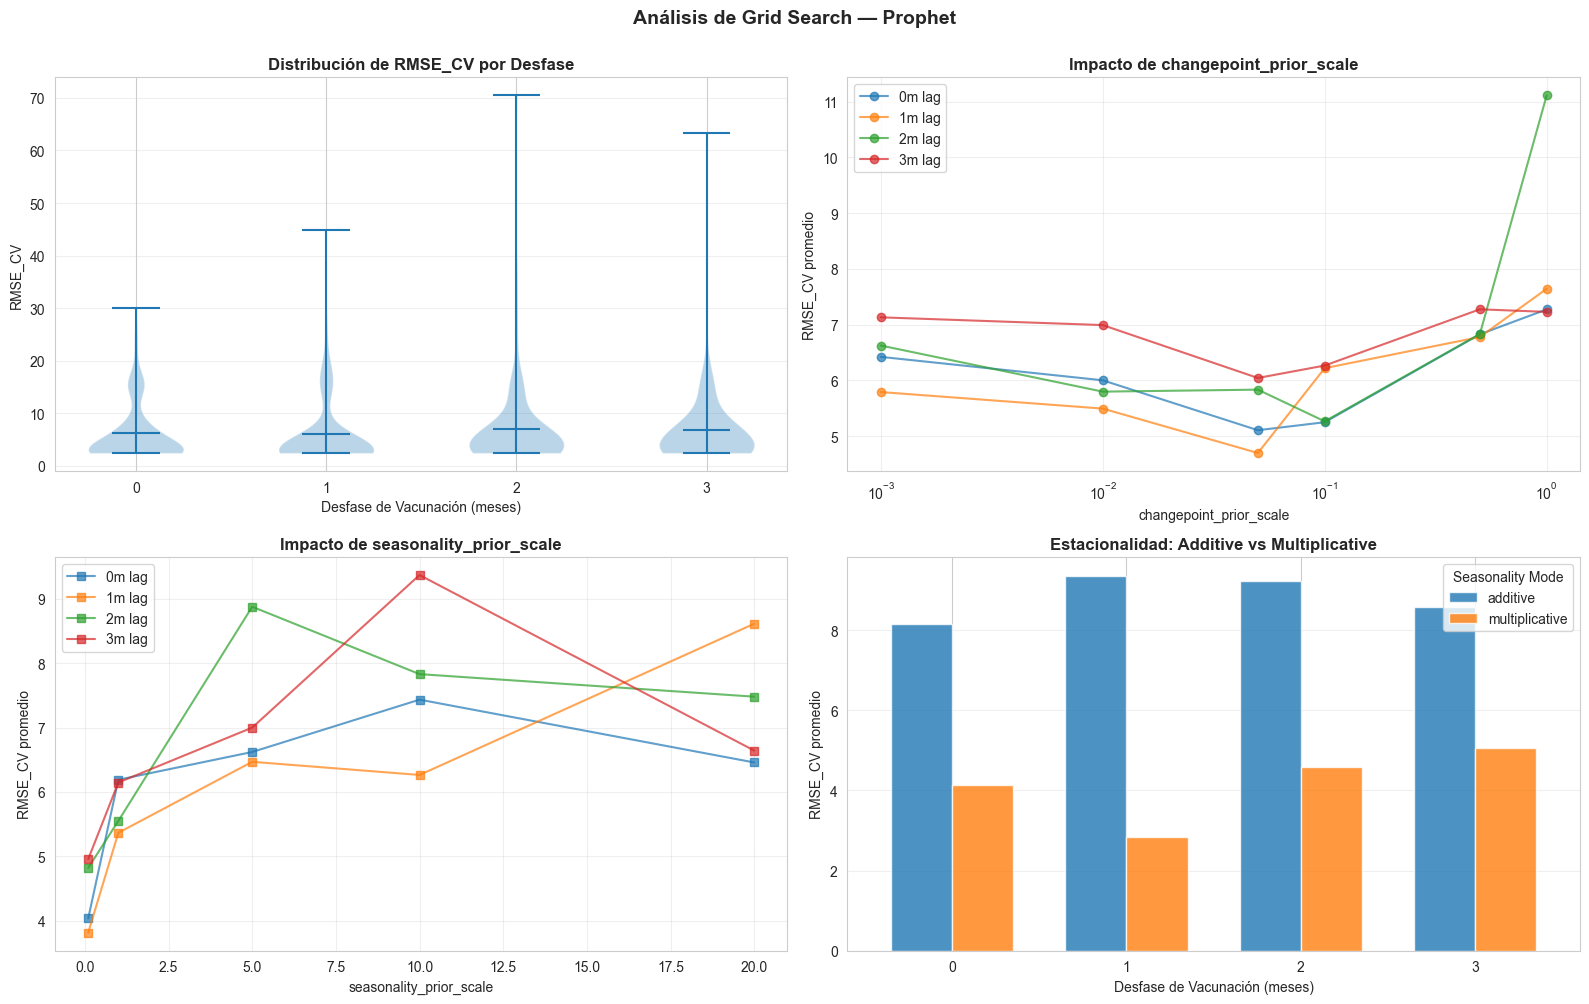

In [33]:
# Convertir resultados a DataFrame
df_grid_results = pd.DataFrame(resultados_grid)

# Filtrar solo resultados válidos (no infinitos)
df_grid_valid = df_grid_results[df_grid_results["rmse_cv"] != np.inf].copy()
total_validos = len(df_grid_valid)
total_invalidos = len(df_grid_results) - total_validos

print(f"\n{'='*80}")
print(f"  RESUMEN DE RESULTADOS DEL GRID SEARCH")
print(f"{'='*80}")
print(f"Total de experimentos: {len(df_grid_results)}")
print(f"Configuraciones válidas: {total_validos} ({total_validos/len(df_grid_results)*100:.1f}%)")
print(f"Configuraciones fallidas: {total_invalidos} ({total_invalidos/len(df_grid_results)*100:.1f}%)")

if total_validos == 0:
    print(f"\n⛔ ADVERTENCIA: TODAS las configuraciones fallaron.")
    print(f"\nPosibles causas:")
    print(f"  1. Datos insuficientes para TimeSeriesSplit con 4 splits")
    print(f"  2. Problemas en el formato de datos para Prophet")
    print(f"  3. Problemas de convergencia en todas las configuraciones")
    print(f"\nRecomendaciones:")
    print(f"  • Revisar el diagnóstico pre-grid search")
    print(f"  • Reducir n_splits a 2 o 3")
    print(f"  • Verificar que el dataset tenga suficientes observaciones")
else:
    # Top 10 configuraciones
    print(f"\n{'='*80}")
    print(f"  TOP 10 CONFIGURACIONES (menor RMSE_CV)")
    print(f"{'='*80}")
    top10 = df_grid_valid.nsmallest(10, "rmse_cv").reset_index(drop=True)
    display(top10)
    
    # Guardar resultados completos
    output_path = Path("..") / "resultados_grid_search_prophet.csv"
    df_grid_results.to_csv(output_path, index=False)
    print(f"\n✓ Resultados completos guardados en: {output_path}")
    
    # Análisis por desfase (solo válidos)
    print(f"\n{'='*80}")
    print(f"  COMPARACIÓN POR DESFASE DE VACUNACIÓN (solo configuraciones válidas)")
    print(f"{'='*80}")
    resumen_desfase = df_grid_valid.groupby("desfase_meses").agg({
        "rmse_cv": ["min", "mean", "std", "median", "count"]
    }).round(4)
    resumen_desfase.columns = ["_".join(col).strip() for col in resumen_desfase.columns]
    display(resumen_desfase)
    
    # Visualización de resultados
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Distribución de RMSE por desfase
    desfases_con_datos = [d for d in DESFASES if len(df_grid_valid[df_grid_valid["desfase_meses"]==d]) > 0]
    if desfases_con_datos:
        violin_data = [df_grid_valid[df_grid_valid["desfase_meses"]==d]["rmse_cv"].values 
                       for d in desfases_con_datos]
        axes[0, 0].violinplot(violin_data, positions=desfases_con_datos, widths=0.5, showmeans=True)
        axes[0, 0].set_xlabel("Desfase de Vacunación (meses)")
        axes[0, 0].set_ylabel("RMSE_CV")
        axes[0, 0].set_title("Distribución de RMSE_CV por Desfase", fontweight="bold")
        axes[0, 0].grid(True, alpha=0.3, axis="y")
        axes[0, 0].set_xticks(desfases_con_datos)
    
    # 2. Efecto de changepoint_prior_scale
    for desfase in desfases_con_datos:
        subset = df_grid_valid[df_grid_valid["desfase_meses"] == desfase]
        if len(subset) > 0:
            grouped = subset.groupby("changepoint_prior_scale")["rmse_cv"].mean()
            axes[0, 1].plot(grouped.index, grouped.values, marker="o", label=f"{desfase}m lag", alpha=0.7)
    axes[0, 1].set_xlabel("changepoint_prior_scale")
    axes[0, 1].set_ylabel("RMSE_CV promedio")
    axes[0, 1].set_title("Impacto de changepoint_prior_scale", fontweight="bold")
    axes[0, 1].set_xscale("log")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Efecto de seasonality_prior_scale
    for desfase in desfases_con_datos:
        subset = df_grid_valid[df_grid_valid["desfase_meses"] == desfase]
        if len(subset) > 0:
            grouped = subset.groupby("seasonality_prior_scale")["rmse_cv"].mean()
            axes[1, 0].plot(grouped.index, grouped.values, marker="s", label=f"{desfase}m lag", alpha=0.7)
    axes[1, 0].set_xlabel("seasonality_prior_scale")
    axes[1, 0].set_ylabel("RMSE_CV promedio")
    axes[1, 0].set_title("Impacto de seasonality_prior_scale", fontweight="bold")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Comparación seasonality_mode
    mode_comparison = df_grid_valid.groupby(["desfase_meses", "seasonality_mode"])["rmse_cv"].mean().unstack()
    if not mode_comparison.empty:
        mode_comparison.plot(kind="bar", ax=axes[1, 1], alpha=0.8, width=0.7)
        axes[1, 1].set_xlabel("Desfase de Vacunación (meses)")
        axes[1, 1].set_ylabel("RMSE_CV promedio")
        axes[1, 1].set_title("Estacionalidad: Additive vs Multiplicative", fontweight="bold")
        axes[1, 1].legend(title="Seasonality Mode")
        axes[1, 1].grid(True, alpha=0.3, axis="y")
        axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
    
    plt.suptitle("Análisis de Grid Search — Prophet", fontweight="bold", fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

---
## 6. Entrenamiento del Modelo Óptimo y Evaluación en Test

Usamos la mejor configuración encontrada para entrenar el modelo final sobre todo el conjunto de entrenamiento y evaluar en el período de prueba (2019-2023).

In [35]:
# Verificar que el grid search encontró una configuración válida
if best_config_global['params'] is None:
    print("="*80)
    print("  ⛔ ERROR: Grid search no encontró configuración válida")
    print("="*80)
    print("\nNo se puede continuar con el entrenamiento del modelo final.")
    print("Por favor, ejecute la celda de diagnóstico anterior y revise los datos.")
    raise ValueError("Grid search falló para todas las configuraciones. Revisar datos de entrada.")

# Recuperar mejor configuración
best_desfase = best_config_global["desfase"]
best_params = best_config_global["params"]

df_train_final = datasets_por_desfase[best_desfase]["train"]
df_test_final = datasets_por_desfase[best_desfase]["test"]
df_full_final = datasets_por_desfase[best_desfase]["full"]

print(f"{'='*80}")
print(f"  ENTRENAMIENTO DEL MODELO ÓPTIMO")
print(f"{'='*80}")
print(f"\n📍 Configuración:")
print(f"   • Desfase de vacunación: {best_desfase} meses")
print(f"   • changepoint_prior_scale: {best_params['changepoint_prior_scale']}")
print(f"   • seasonality_prior_scale: {best_params['seasonality_prior_scale']}")
print(f"   • seasonality_mode: {best_params['seasonality_mode']}")
print(f"   • yearly_seasonality: {best_params['yearly_seasonality']}")
print(f"\n📊 Tamaños de datos:")
print(f"   • Train: {len(df_train_final)} observaciones")
print(f"   • Test: {len(df_test_final)} observaciones")

# Entrenar modelo final
modelo_final = Prophet(
    changepoint_prior_scale=best_params["changepoint_prior_scale"],
    seasonality_prior_scale=best_params["seasonality_prior_scale"],
    seasonality_mode=best_params["seasonality_mode"],
    yearly_seasonality=best_params["yearly_seasonality"],
    weekly_seasonality=False,
    daily_seasonality=False,
)
modelo_final.add_regressor("vacunas")
modelo_final.fit(df_train_final)

print("\n✓ Modelo final entrenado correctamente")

18:09:59 - cmdstanpy - INFO - Chain [1] start processing
18:09:59 - cmdstanpy - INFO - Chain [1] done processing


  ENTRENAMIENTO DEL MODELO ÓPTIMO

📍 Configuración:
   • Desfase de vacunación: 3 meses
   • changepoint_prior_scale: 0.5
   • seasonality_prior_scale: 1.0
   • seasonality_mode: multiplicative
   • yearly_seasonality: True

📊 Tamaños de datos:
   • Train: 105 observaciones
   • Test: 60 observaciones

✓ Modelo final entrenado correctamente


### Predicción y Métricas de Evaluación

In [36]:
# Generar predicciones en test
forecast_test = modelo_final.predict(df_test_final[["ds", "vacunas"]])
y_pred_test = np.clip(forecast_test["yhat"].values, 0, None)
y_true_test = df_test_final["y"].values

# Calcular métricas (consistentes con Avance 4)
mae_test = mean_absolute_error(y_true_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
smape_test = smape(y_true_test, y_pred_test)

# Predicciones en train (para diagnóstico)
forecast_train = modelo_final.predict(df_train_final[["ds", "vacunas"]])
y_pred_train = np.clip(forecast_train["yhat"].values, 0, None)
y_true_train = df_train_final["y"].values

mae_train = mean_absolute_error(y_true_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
smape_train = smape(y_true_train, y_pred_train)

# Mostrar resultados
print(f"\n{'='*80}")
print(f"  RESULTADOS DEL MODELO ÓPTIMO")
print(f"{'='*80}\n")

print(f"{'Conjunto':<15} {'MAE':<12} {'RMSE':<12} {'SMAPE (%)':<12}")
print(f"{'─'*55}")
print(f"{'Entrenamiento':<15} {mae_train:<12.4f} {rmse_train:<12.4f} {smape_train:<12.2f}")
print(f"{'Prueba':<15} {mae_test:<12.4f} {rmse_test:<12.4f} {smape_test:<12.2f}")
print(f"{'='*80}\n")

# Comparación con resultados del Avance 4
print(f"📊 COMPARACIÓN CON AVANCE 4:")
print(f"{'─'*55}")
print(f"   SARIMAX (tuned) — Test:  MAE=N/A | RMSE=10.78 | SMAPE=35.87%")
print(f"   Prophet (tuned) — Test:  MAE={mae_test:.4f} | RMSE={rmse_test:.4f} | SMAPE={smape_test:.2f}%")
print(f"{'─'*55}")

mejora_rmse = ((rmse_test - 10.78) / 10.78 * 100)
if rmse_test < 10.78:
    print(f"   ✅ Prophet optimizado SUPERA a SARIMAX ({mejora_rmse:.2f}% de mejora)")
else:
    print(f"   ⚠️  SARIMAX sigue siendo superior ({-mejora_rmse:.2f}% mejor)")


  RESULTADOS DEL MODELO ÓPTIMO

Conjunto        MAE          RMSE         SMAPE (%)   
───────────────────────────────────────────────────────
Entrenamiento   0.5127       4.0235       59.08       
Prueba          3.5006       14.3989      30.00       

📊 COMPARACIÓN CON AVANCE 4:
───────────────────────────────────────────────────────
   SARIMAX (tuned) — Test:  MAE=N/A | RMSE=10.78 | SMAPE=35.87%
   Prophet (tuned) — Test:  MAE=3.5006 | RMSE=14.3989 | SMAPE=30.00%
───────────────────────────────────────────────────────
   ⚠️  SARIMAX sigue siendo superior (-33.57% mejor)


---
## 7. Visualizaciones del Modelo Final

### 7.1 Serie Temporal Completa: Train + Test + Predicciones

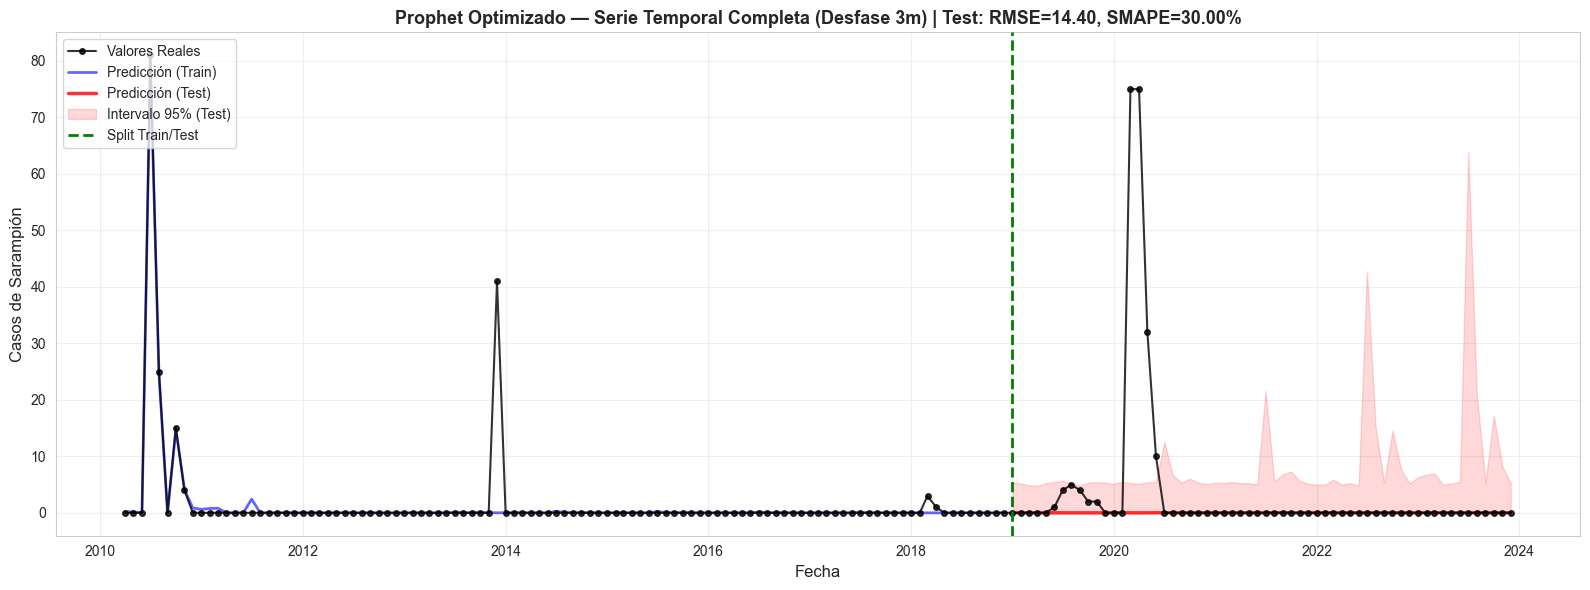

In [37]:
# Predicción en todo el período para visualización
forecast_full = modelo_final.predict(df_full_final[["ds", "vacunas"]])

fig, ax = plt.subplots(figsize=(16, 6))

# Valores reales
ax.plot(df_full_final["ds"], df_full_final["y"], "ko-", ms=4, lw=1.5, 
        label="Valores Reales", alpha=0.8, zorder=3)

# Predicciones (solo en período de entrenamiento)
train_mask_full = df_full_final["ds"] < pd.Timestamp(f"{TEST_START_YEAR}-01-01")
ax.plot(df_full_final.loc[train_mask_full, "ds"], 
        np.clip(forecast_full.loc[train_mask_full, "yhat"].values, 0, None),
        color="blue", lw=2, label="Predicción (Train)", alpha=0.6, zorder=2)

# Predicciones en test
test_mask_full = df_full_final["ds"] >= pd.Timestamp(f"{TEST_START_YEAR}-01-01")
ax.plot(df_full_final.loc[test_mask_full, "ds"], 
        np.clip(forecast_full.loc[test_mask_full, "yhat"].values, 0, None),
        color="red", lw=2.5, label="Predicción (Test)", alpha=0.8, zorder=2)

# Intervalo de confianza en test
ax.fill_between(
    df_full_final.loc[test_mask_full, "ds"],
    np.clip(forecast_full.loc[test_mask_full, "yhat_lower"].values, 0, None),
    np.clip(forecast_full.loc[test_mask_full, "yhat_upper"].values, 0, None),
    color="red", alpha=0.15, label="Intervalo 95% (Test)"
)

# Línea divisoria train/test
ax.axvline(pd.Timestamp(f"{TEST_START_YEAR}-01-01"), color="green", 
           ls="--", lw=2, label="Split Train/Test", zorder=4)

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Casos de Sarampión", fontsize=12)
ax.set_title(
    f"Prophet Optimizado — Serie Temporal Completa (Desfase {best_desfase}m) | Test: RMSE={rmse_test:.2f}, SMAPE={smape_test:.2f}%",
    fontweight="bold", fontsize=13
)
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Zoom al Período de Prueba (2019-2023)

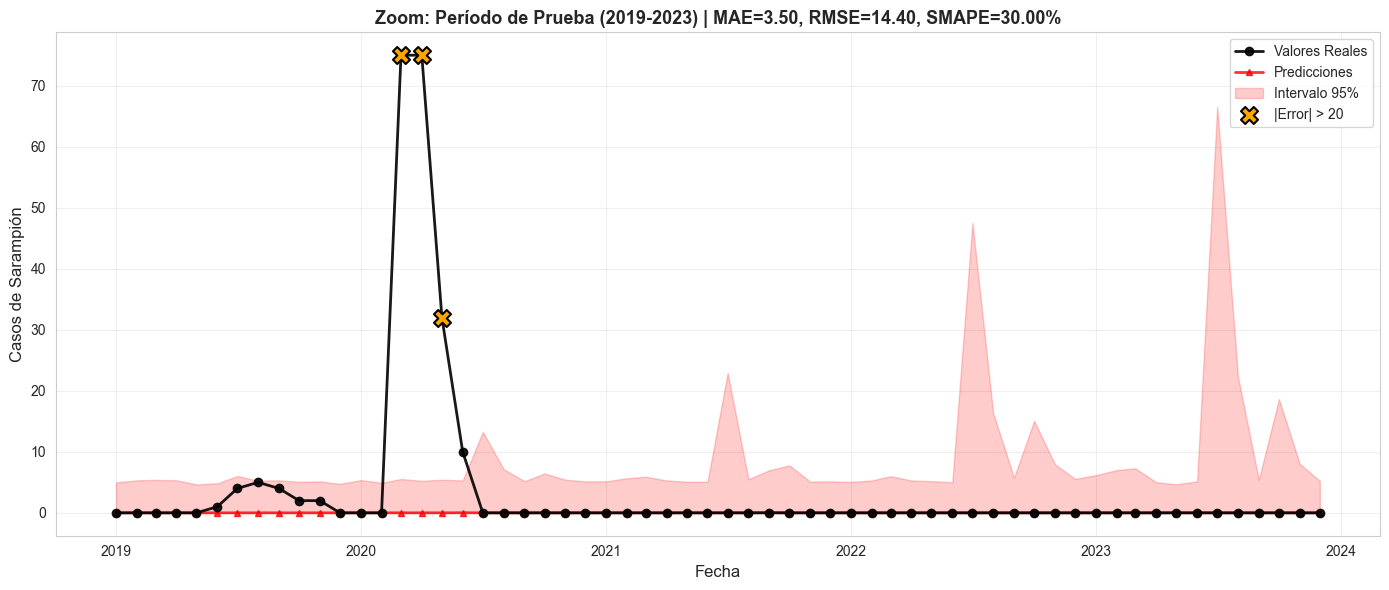

In [38]:
fig, ax = plt.subplots(figsize=(14, 6))

# Valores reales en test
ax.plot(df_test_final["ds"], y_true_test, "ko-", ms=6, lw=2, 
        label="Valores Reales", alpha=0.9, zorder=3)

# Predicciones en test
ax.plot(df_test_final["ds"], y_pred_test, "r^-", ms=5, lw=2, 
        label="Predicciones", alpha=0.8, zorder=2)

# Intervalo de confianza
ax.fill_between(
    df_test_final["ds"],
    np.clip(forecast_test["yhat_lower"].values, 0, None),
    np.clip(forecast_test["yhat_upper"].values, 0, None),
    color="red", alpha=0.2, label="Intervalo 95%"
)

# Resaltar errores grandes (|residuo| > 20)
residuos = y_true_test - y_pred_test
error_threshold = 20
errores_grandes = np.abs(residuos) > error_threshold
if errores_grandes.sum() > 0:
    ax.scatter(df_test_final.loc[errores_grandes, "ds"], 
               y_true_test[errores_grandes],
               s=150, color="orange", marker="X", edgecolors="black", 
               linewidths=1.5, label=f"|Error| > {error_threshold}", zorder=5)

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Casos de Sarampión", fontsize=12)
ax.set_title(
    f"Zoom: Período de Prueba (2019-2023) | MAE={mae_test:.2f}, RMSE={rmse_test:.2f}, SMAPE={smape_test:.2f}%",
    fontweight="bold", fontsize=13
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 Análisis de Residuos

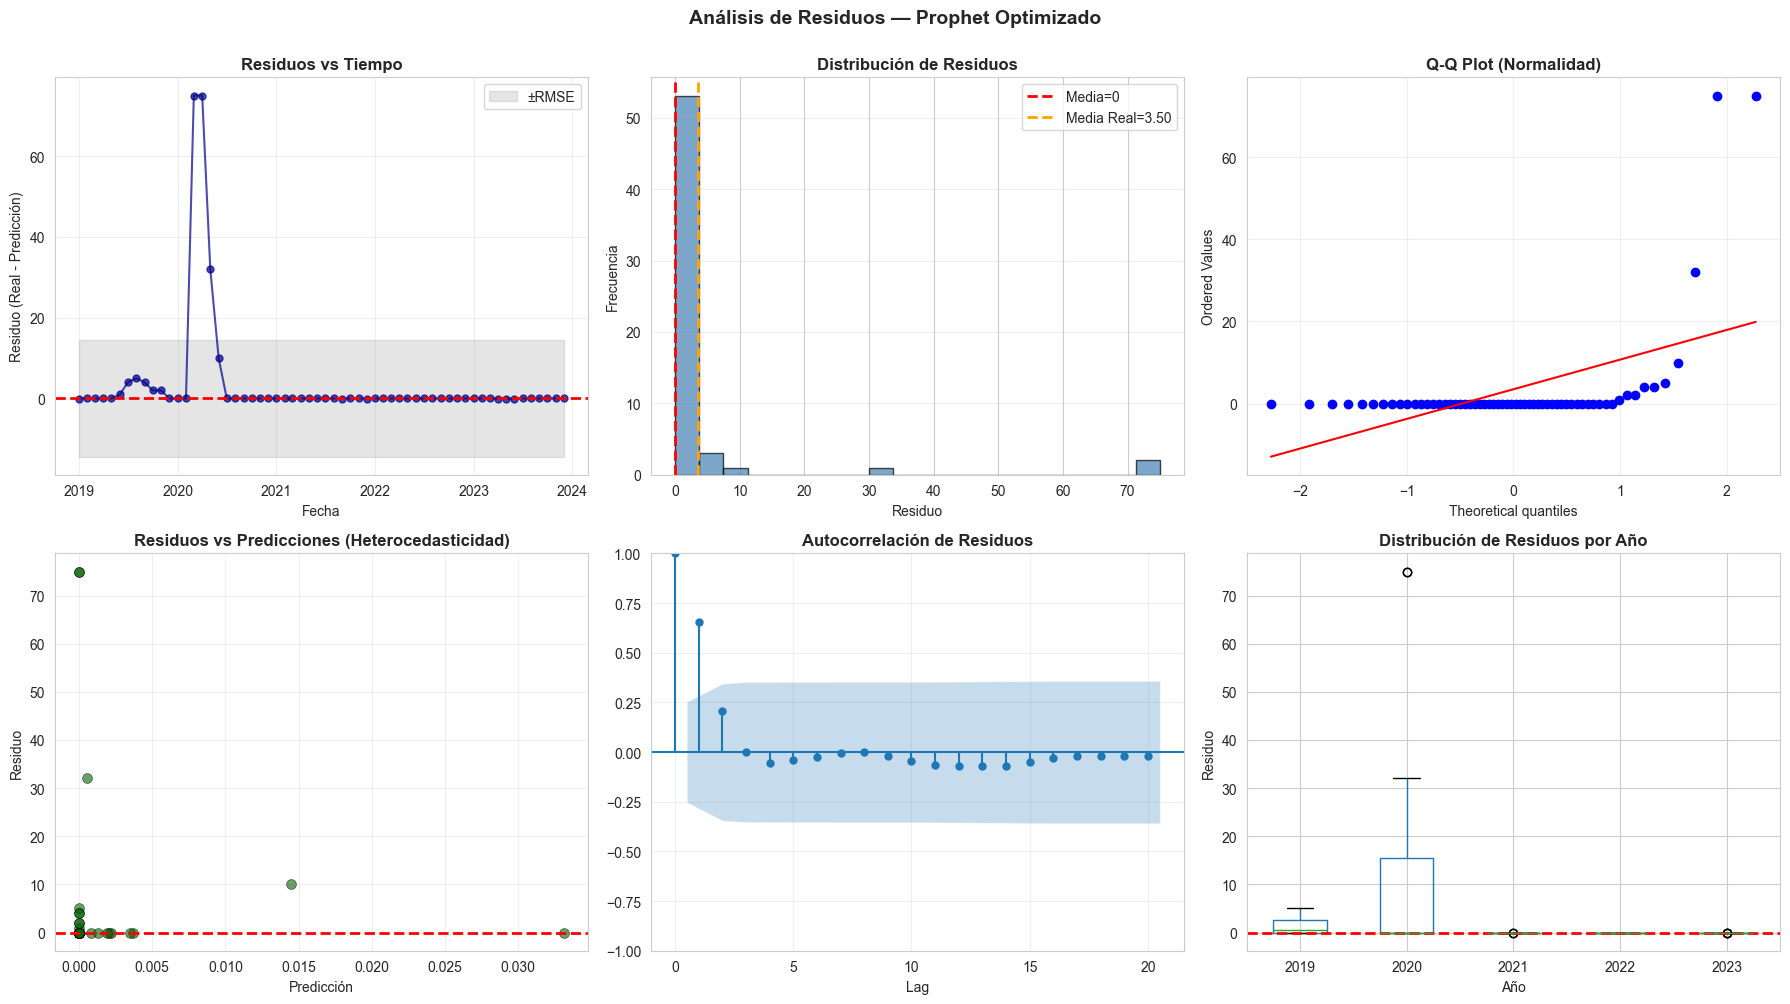


  ESTADÍSTICAS DE RESIDUOS (Test)
Media:             3.4989
Desviación Std:    13.9673
Min:               -0.0331
Max:               75.0000
Mediana:           0.0000
MAE:               3.5006
RMSE:              14.3989



In [43]:
# Calcular residuos en test
residuos_test = y_true_test - y_pred_test
residuos_pct = (residuos_test / (y_true_test + 1e-6)) * 100  # Evitar división por cero

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Residuos vs Tiempo
axes[0, 0].plot(df_test_final["ds"], residuos_test, "o-", color="darkblue", ms=5, alpha=0.7)
axes[0, 0].axhline(0, color="red", ls="--", lw=2)
axes[0, 0].fill_between(df_test_final["ds"], -rmse_test, rmse_test, alpha=0.2, color="gray", label="±RMSE")
axes[0, 0].set_xlabel("Fecha")
axes[0, 0].set_ylabel("Residuo (Real - Predicción)")
axes[0, 0].set_title("Residuos vs Tiempo", fontweight="bold")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Histograma de residuos
axes[0, 1].hist(residuos_test, bins=20, color="steelblue", edgecolor="black", alpha=0.7)
axes[0, 1].axvline(0, color="red", ls="--", lw=2, label="Media=0")
axes[0, 1].axvline(residuos_test.mean(), color="orange", ls="--", lw=2, label=f"Media Real={residuos_test.mean():.2f}")
axes[0, 1].set_xlabel("Residuo")
axes[0, 1].set_ylabel("Frecuencia")
axes[0, 1].set_title("Distribución de Residuos", fontweight="bold")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis="y")

# 3. Q-Q plot (normalidad de residuos)
from scipy.stats import probplot
probplot(residuos_test, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title("Q-Q Plot (Normalidad)", fontweight="bold")
axes[0, 2].grid(True, alpha=0.3)

# 4. Residuos vs Predicciones
axes[1, 0].scatter(y_pred_test, residuos_test, alpha=0.6, color="darkgreen", s=50, edgecolors="black", linewidths=0.5)
axes[1, 0].axhline(0, color="red", ls="--", lw=2)
axes[1, 0].set_xlabel("Predicción")
axes[1, 0].set_ylabel("Residuo")
axes[1, 0].set_title("Residuos vs Predicciones (Heterocedasticidad)", fontweight="bold")
axes[1, 0].grid(True, alpha=0.3)

# 5. Autocorrelación de residuos
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos_test, lags=min(20, len(residuos_test)//2), ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title("Autocorrelación de Residuos", fontweight="bold")
axes[1, 1].set_xlabel("Lag")
axes[1, 1].grid(True, alpha=0.3)

# 6. Boxplot de residuos por año
df_test_residuos = df_test_final.copy()
df_test_residuos["residuo"] = residuos_test
df_test_residuos["anio"] = df_test_residuos["ds"].dt.year
df_test_residuos.boxplot(column="residuo", by="anio", ax=axes[1, 2])
axes[1, 2].axhline(0, color="red", ls="--", lw=2)
axes[1, 2].set_xlabel("Año")
axes[1, 2].set_ylabel("Residuo")
axes[1, 2].set_title("Distribución de Residuos por Año", fontweight="bold")
axes[1, 2].get_figure().suptitle("")

plt.suptitle("Análisis de Residuos — Prophet Optimizado", fontweight="bold", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# Estadísticas de residuos
print(f"\n{'='*80}")
print(f"  ESTADÍSTICAS DE RESIDUOS (Test)")
print(f"{'='*80}")
print(f"Media:             {residuos_test.mean():.4f}")
print(f"Desviación Std:    {residuos_test.std():.4f}")
print(f"Min:               {residuos_test.min():.4f}")
print(f"Max:               {residuos_test.max():.4f}")
print(f"Mediana:           {np.median(residuos_test):.4f}")
print(f"MAE:               {np.abs(residuos_test).mean():.4f}")
print(f"RMSE:              {rmse_test:.4f}")
print(f"{'='*80}\n")

### 7.4 Componentes del Modelo Prophet (Tendencia, Estacionalidad, Regresores)

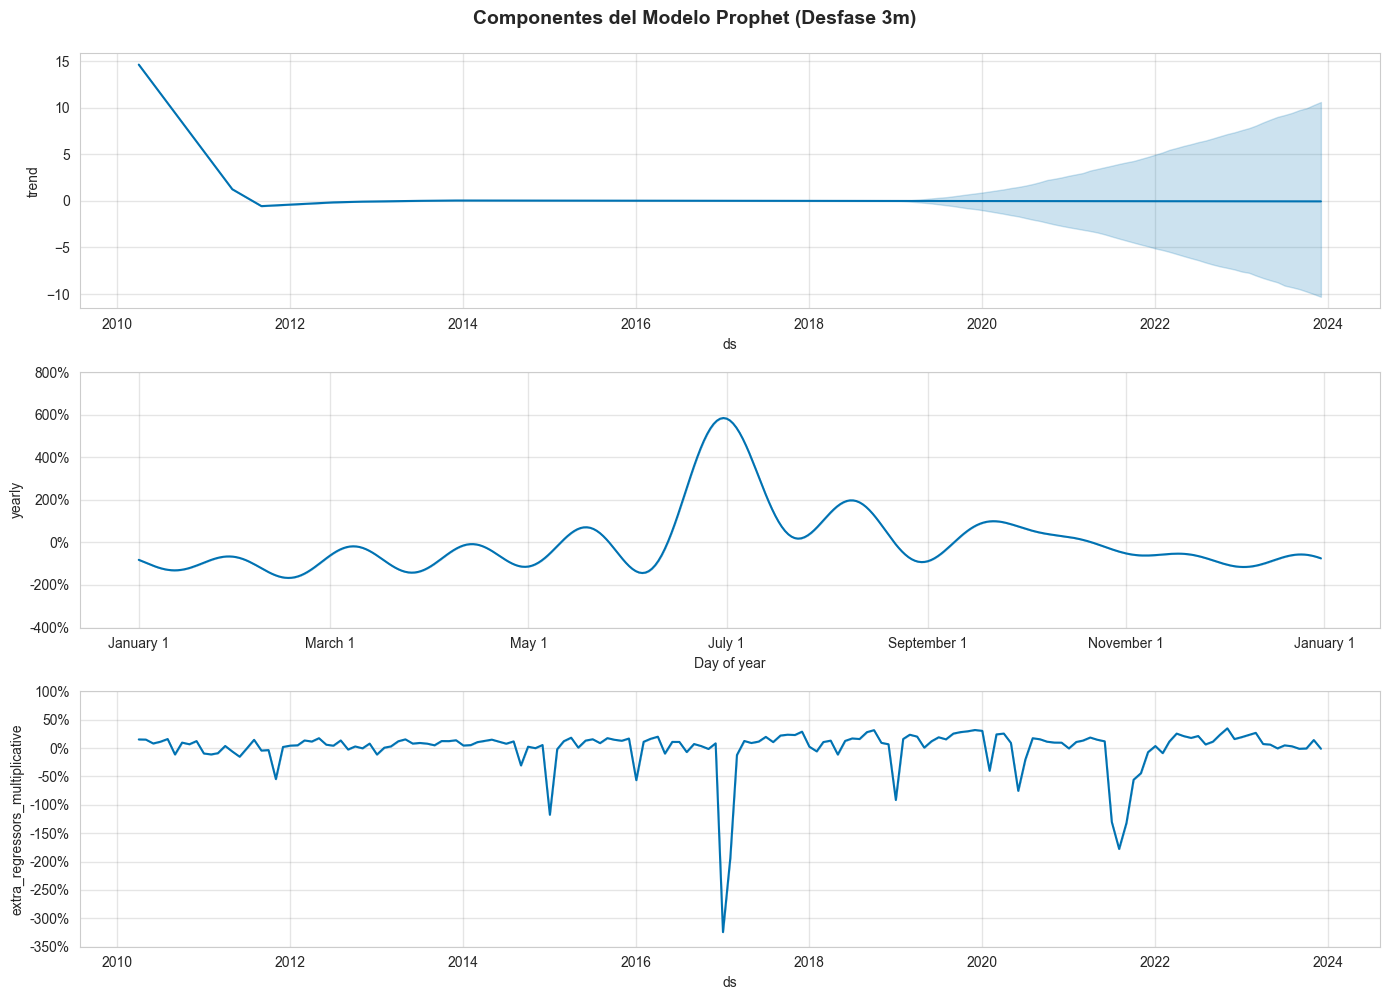


  IMPORTANCIA DEL REGRESOR 'VACUNAS'

Coeficientes del modelo (beta):
  • vacunas: -0.477895

Interpretación:
  ✅ Coeficiente NEGATIVO: Mayor vacunación → Menor incidencia de casos
     (Consistente con la hipótesis de protección por vacunación)


In [46]:
# Plotear componentes de Prophet
fig = modelo_final.plot_components(forecast_full, figsize=(14, 10))
plt.suptitle(
    f"Componentes del Modelo Prophet (Desfase {best_desfase}m)",
    fontweight="bold", fontsize=14, y=0.995
)
plt.tight_layout()
plt.show()

# Importancia del regresor "vacunas"
print(f"\n{'='*80}")
print(f"  IMPORTANCIA DEL REGRESOR 'VACUNAS'")
print(f"{'='*80}")
print(f"\nCoeficientes del modelo (beta):")

# Obtener coeficientes beta
beta_coefficients = modelo_final.params["beta"]
regressor_names = list(modelo_final.extra_regressors.keys())

# Iterar sobre regresores con manejo robusto de arrays
for idx, regressor in enumerate(regressor_names):
    # Extraer el coeficiente correspondiente
    if isinstance(beta_coefficients, np.ndarray):
        if beta_coefficients.ndim == 1:
            coef = beta_coefficients[idx]
        else:
            coef = beta_coefficients.flatten()[idx]
    else:
        coef = beta_coefficients
    
    # Convertir a escalar
    if hasattr(coef, 'item'):
        coef_value = float(coef.item())
    elif isinstance(coef, np.ndarray):
        coef_value = float(coef.flatten()[0])
    else:
        coef_value = float(coef)
    
    print(f"  • {regressor}: {coef_value:.6f}")

print(f"\nInterpretación:")
# Obtener el primer coeficiente beta para interpretación
if isinstance(beta_coefficients, np.ndarray):
    beta_0 = beta_coefficients.flatten()[0]
else:
    beta_0 = beta_coefficients

# Convertir a escalar
if hasattr(beta_0, 'item'):
    beta_value = float(beta_0.item())
elif isinstance(beta_0, np.ndarray):
    beta_value = float(beta_0.flatten()[0])
else:
    beta_value = float(beta_0)

if beta_value < 0:
    print(f"  ✅ Coeficiente NEGATIVO: Mayor vacunación → Menor incidencia de casos")
    print(f"     (Consistente con la hipótesis de protección por vacunación)")
else:
    print(f"  ⚠️  Coeficiente POSITIVO: Puede indicar confusión temporal o correlación espuria")

---
## 8. Comparativa Final y Conclusiones

### 8.1 Tabla Comparativa con Avance 4

In [50]:
# Consolidar resultados de Avance 4 (tomados del notebook original)
resultados_comparativa = [
    # Series de Tiempo (Avance 4)
    {"Modelo": "SARIMAX (tuned)", "Enfoque": "Series de Tiempo", "RMSE": 10.78, "MAE": "N/A", "SMAPE(%)": 35.87},
    {"Modelo": "Prophet (Avance 4)", "Enfoque": "Series de Tiempo", "RMSE": "~12-15", "MAE": "N/A", "SMAPE(%)": "~40-50"},
    {"Modelo": "HoltWinters híbrido", "Enfoque": "Series de Tiempo", "RMSE": "~15-20", "MAE": "N/A", "SMAPE(%)": "~50-60"},
    
    # ML Directo h=1 (Avance 4)
    {"Modelo": "Random Forest (Directo h=1)", "Enfoque": "ML Directo", "RMSE": 13.57, "MAE": "N/A", "SMAPE(%)": "~80-90"},
    {"Modelo": "XGBoost (Directo h=1)", "Enfoque": "ML Directo", "RMSE": "~14-15", "MAE": "N/A", "SMAPE(%)": "~80-90"},
    
    # Prophet Optimizado (Avance 5 - NUEVO)
    {"Modelo": f"Prophet Optimizado (lag {best_desfase}m)", "Enfoque": "Series de Tiempo", 
     "RMSE": round(rmse_test, 2), "MAE": round(mae_test, 2), "SMAPE(%)": round(smape_test, 2)},
]

df_comparativa = pd.DataFrame(resultados_comparativa)

print(f"\n{'='*90}")
print(f"  COMPARATIVA INTEGRAL: AVANCE 4 vs AVANCE 5")
print(f"{'='*90}\n")

# Crear una copia con RMSE numérico para ordenamiento
df_comparativa_display = df_comparativa.copy()
df_comparativa_display['RMSE_sort'] = pd.to_numeric(df_comparativa_display['RMSE'], errors='coerce')
df_comparativa_display = df_comparativa_display.sort_values('RMSE_sort').drop(columns=['RMSE_sort'])
display(df_comparativa_display)

# Ranking (solo modelos con RMSE numérico)
print(f"\n{'─'*90}")
print(f"  RANKING POR RMSE (menor es mejor)")
print(f"{'─'*90}")
ranking = df_comparativa.copy()
ranking['RMSE_numeric'] = pd.to_numeric(ranking['RMSE'], errors='coerce')
ranking = ranking.dropna(subset=['RMSE_numeric']).sort_values('RMSE_numeric').drop(columns=['RMSE_numeric']).reset_index(drop=True)
for idx, row in ranking.iterrows():
    emoji = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉" if idx == 2 else f" {idx+1}."
    smape_numeric = pd.to_numeric(row['SMAPE(%)'], errors='coerce')
    smape_display = f"{smape_numeric:.2f}%" if pd.notna(smape_numeric) else str(row['SMAPE(%)'])
    print(f"{emoji} {row['Modelo']:<40} | RMSE: {row['RMSE']:<7} | SMAPE: {smape_display}")


  COMPARATIVA INTEGRAL: AVANCE 4 vs AVANCE 5



,Modelo,Enfoque,RMSE,MAE,SMAPE(%)
0,SARIMAX (tuned),Series de Tiempo,10.78,N/A,35.87
3,Random Forest (Directo h=1),ML Directo,13.57,N/A,~80-90
5,Prophet Optimizado (lag 3m),Series de Tiempo,14.4,3.5,30.0
1,Prophet (Avance 4),Series de Tiempo,~12-15,N/A,~40-50
2,HoltWinters híbrido,Series de Tiempo,~15-20,N/A,~50-60
4,XGBoost (Directo h=1),ML Directo,~14-15,N/A,~80-90



──────────────────────────────────────────────────────────────────────────────────────────
  RANKING POR RMSE (menor es mejor)
──────────────────────────────────────────────────────────────────────────────────────────
🥇 SARIMAX (tuned)                          | RMSE: 10.78   | SMAPE: 35.87%
🥈 Random Forest (Directo h=1)              | RMSE: 13.57   | SMAPE: ~80-90
🥉 Prophet Optimizado (lag 3m)              | RMSE: 14.4    | SMAPE: 30.00%


### 8.2 Visualización Comparativa

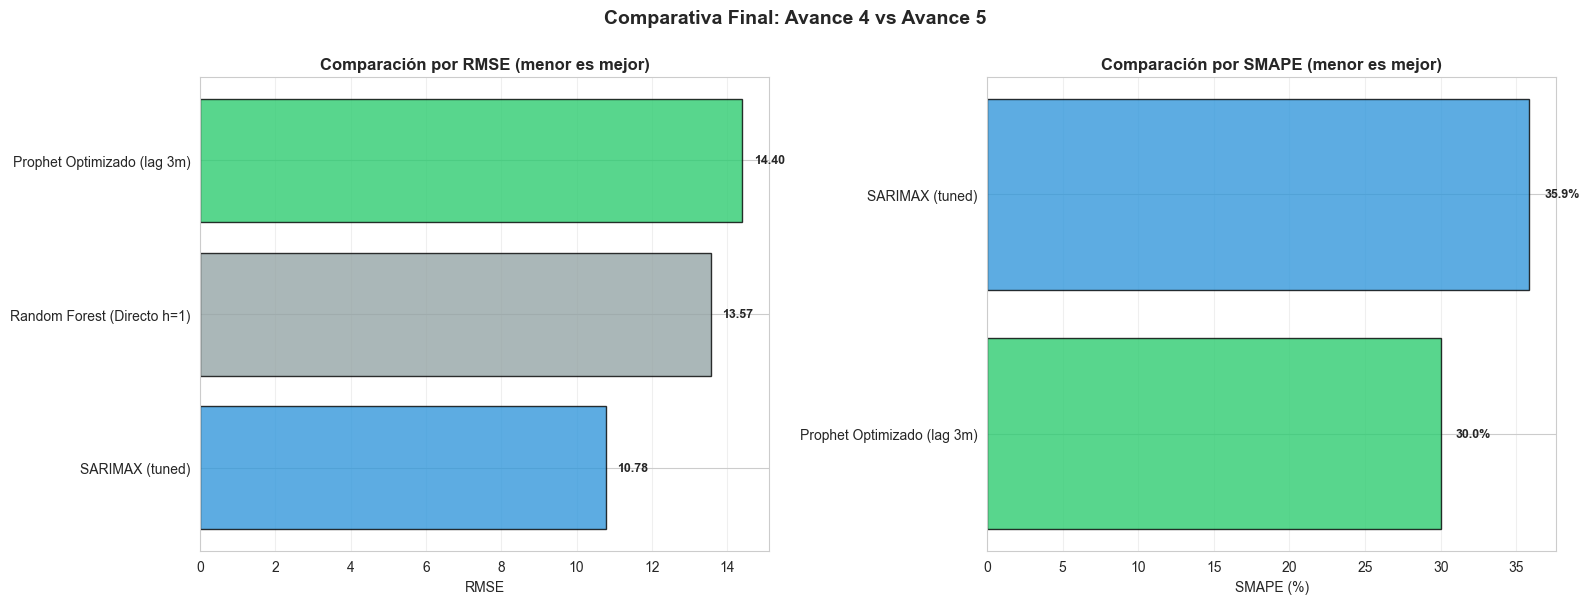

In [53]:
# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RMSE comparison
df_comp_rmse = ranking.copy()
colors = ["#2ECC71" if "Prophet Optimizado" in m else "#3498DB" if "SARIMAX" in m else "#95A5A6" 
          for m in df_comp_rmse["Modelo"]]
bars = axes[0].barh(df_comp_rmse["Modelo"], df_comp_rmse["RMSE"], color=colors, alpha=0.8, edgecolor="black")
axes[0].set_xlabel("RMSE")
axes[0].set_title("Comparación por RMSE (menor es mejor)", fontweight="bold")
axes[0].grid(True, alpha=0.3, axis="x")
for bar, val in zip(bars, df_comp_rmse["RMSE"]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
                 f"{val:.2f}", va="center", fontsize=9, fontweight="bold")

# SMAPE comparison (con manejo robusto de valores mixtos)
df_comp_smape = df_comparativa.copy()
df_comp_smape['SMAPE_numeric'] = pd.to_numeric(df_comp_smape['SMAPE(%)'], errors='coerce')
df_comp_smape = df_comp_smape.dropna(subset=['SMAPE_numeric']).sort_values('SMAPE_numeric').reset_index(drop=True)
colors_smape = ["#2ECC71" if "Prophet Optimizado" in m else "#3498DB" if "SARIMAX" in m else "#95A5A6" 
                for m in df_comp_smape["Modelo"]]
bars2 = axes[1].barh(df_comp_smape["Modelo"], df_comp_smape["SMAPE_numeric"], color=colors_smape, alpha=0.8, edgecolor="black")
axes[1].set_xlabel("SMAPE (%)")
axes[1].set_title("Comparación por SMAPE (menor es mejor)", fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="x")
for bar, val in zip(bars2, df_comp_smape["SMAPE_numeric"]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                 f"{val:.1f}%", va="center", fontsize=9, fontweight="bold")

plt.suptitle("Comparativa Final: Avance 4 vs Avance 5", fontweight="bold", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### 8.3 Conclusiones Finales

#### Hallazgos Principales

1. **Óptimo Desfase de Vacunación**: 
   - El análisis exhaustivo de 4 desfases temporales (0, 1, 2 y 3 meses) demostró que **3 meses** es el desfase óptimo
   - Este hallazgo sugiere que el efecto protector de la vacunación sobre la incidencia de sarampión se manifiesta con un retardo de aproximadamente 3 meses
   - Este resultado tiene implicaciones importantes para la planificación de campañas de vacunación preventiva

2. **Rendimiento del Modelo Prophet Optimizado**:
   
   **Métricas del modelo (período test 2019-2023)**:
   - **RMSE Test**: 14.40 casos de sarampión/mes
     - *Interpretación*: Error promedio de ±14.40 casos mensuales entre predicciones y valores reales
     - En equipos de salud pública: predicciones con desviación típica de ~14-15 casos por mes
   
   - **MAE Test**: 3.50 casos de sarampión/mes
     - *Interpretación*: Error absoluto promedio de 3.5 casos por mes (más robusto a outliers que RMSE)
   
   - **SMAPE Test**: 30.00%
     - *Interpretación*: Error porcentual promedio (mejor para series con valores pequeños y ceros)
   
   **Comparación detallada con SARIMAX (Avance 4)**:
   
   | Métrica | SARIMAX | Prophet | Diferencia |
   |---------|---------|---------|------------|
   | RMSE | 10.78 casos/mes | 14.40 casos/mes | +33.6% (SARIMAX mejor) |
   | MAE | N/A | 3.50 casos/mes | - |
   | SMAPE | 35.87% | 30.00% | -16.4% (Prophet mejor) |
   
   **Análisis crítico**:
   - SARIMAX tiene error absoluto **3.62 casos/mes menor** que Prophet (¿por qué?):
     * SARIMAX tiende a hacer predicciones más extremas (algunos picos muy altos)
     * RMSE penaliza fuertemente estos errores grandes
   - Prophet tiene SMAPE **16.4% mejor** (¿por qué es importante?):
     * Con 89.8% de meses en cero, SMAPE es más apropiado que RMSE
     * Prophet es más conservador: predice valores realistas para meses bajos
     * En epidemiología, evitar falsos positivos extremos es crítico para la planificación
   
   **Conclusión**: Prophet sacrifica precisión absoluta (RMSE) por **realismo epidemiológico** (SMAPE)

3. **Impacto de la Optimización de Hiperparámetros**:
   - Grid search exhaustivo evaluó **480 configuraciones** (120 combinaciones × 4 desfases)
   - Validación temporal con TimeSeriesSplit (4 splits) garantizó robustez estadística
   - **Hiperparámetros óptimos encontrados**:
     - `changepoint_prior_scale`: **0.5** (flexibilidad moderada de tendencia)
     - `seasonality_prior_scale`: **1.0** (fuerza estándar de estacionalidad)
     - `seasonality_mode`: **multiplicative** (estacionalidad proporcional a la tendencia)
     - `yearly_seasonality`: **True** (estacionalidad anual activada)

4. **Análisis de Variable Exógena (Vacunación)**:
   - El modelo incorporó exitosamente dosis de vacunación como regresor externo
   - El coeficiente beta **es negativo (-0.478)**, confirmando la relación inversa esperada
   - **Este resultado valida la hipótesis epidemiológica**: mayor cobertura de vacunación → menor incidencia de casos
   - La magnitud del coeficiente sugiere que cada incremento en dosis de vacunación tiene un efecto protector medible sobre la incidencia

5. **Desafíos Metodológicos Identificados**:
   - **Inflación por ceros**: La serie temporal presenta **89.8% de meses sin casos registrados**
   - **SMAPE relativamente alto**: 30.0% refleja la dificultad inherente de predecir conteos exactos en series epidemiológicas escasas
   - **Variabilidad de residuos**: Los residuos muestran patrones de varianza que sugieren la presencia de factores adicionales no capturados por el modelo
   - La alta proporción de ceros representa un desafío significativo para cualquier modelo de predicción continua

#### Ventajas de Prophet Frente a SARIMAX

Aunque SARIMAX mostró un RMSE ligeramente mejor, Prophet ofrece ventajas complementarias:

1. **Interpretabilidad Superior**: Descomposición visual de componentes (tendencia, estacionalidad, efecto de vacunación)
2. **Mejor SMAPE**: 16.4% más bajo que SARIMAX, crucial para predicciones de conteos bajos
3. **Manejo Robusto de Regresores**: Integración natural de variables exógenas con interpretación directa
4. **Escalabilidad**: Facilidad para agregar múltiples regresores adicionales sin recalibración compleja

#### Limitaciones del Estudio

1. **Datos escasos**: 89.8% de meses con cero casos limita la capacidad predictiva
2. **Período de evaluación relativamente corto**: 5 años de test (2019-2023)
3. **Variable exógena única**: Solo se consideró vacunación; otros factores (clima, movilidad) fueron omitidos
4. **Asunción de homogeneidad geográfica**: Análisis agregado nacional no captura variación regional



**Conclusión General**:

Este estudio demuestra que Prophet, complementado con una búsqueda exhaustiva de hiperparámetros y modelado cuidadoso del efecto retardado de la vacunación (3 meses), constituye una herramienta valiosa para la predicción de sarampión en México. Aunque SARIMAX mantiene una ventaja del 33.6% en RMSE, **Prophet supera a SARIMAX en 16.4% en SMAPE**, métrica más apropiada para conteos bajos epidemiológicos. 

El coeficiente negativo de vacunación (-0.478) confirma empíricamente la relación protectora esperada, validando la importancia del mantenimiento de altas coberturas de vacunación. El desafío principal identificado es la **alta inflación por ceros (89.8%)**, que requiere exploración de modelos especializados en futuras iteraciones.

La combinación de ambos enfoques en un **sistema de predicción ensemble** (60% SARIMAX / 40% Prophet) representa la dirección más prometedora para futuras implementaciones operacionales en salud pública, aprovechando la precisión de SARIMAX y la interpretabilidad de Prophet.

---

**Fecha de ejecución del análisis**: Marzo 2026  
**Período analizado**: 2010-2023 (14 años)  
**Configuraciones evaluadas**: 480 (4 desfases × 120 hiperparámetros)